 Contains following items in sequence mentioned below:
1.Introduction & Hypothesis
2. Data Description
3. Methodology
4. Analysis
5. Robustness Checks
6. Results Summary
7. Limitations
8. Conclusion

## 1. Introduction and Hypothesis

ESG(Environmental,Social,Governance) score measures how sustainable a company is based on their actions in environmental , social 
and governance related areas of their business. 

The objective of this study is to examine whether being more ESG compliant makes a company more risk resilient. 
Primary hypothesis to define this objective is as follows:

- __H1(Primary Hypothesis):__ _Companies with higher ESG score exhibit greater resilience compared to companies with lower ESG score during periods of market stress._
- __H1(Null Hypothesis):__ _ESG compliance do not play any role in deciding how company performs during market stress days._

Based on results of primary hypothesis we will formulate complementary hypotheis and robustness checks(if needed)

## 2. Data Description

3 datasets are used, specified as follows:

- Market index:(2024-25): Using Yahoo Finance API(https://finance.yahoo.com/quote/API/),via python yfinance library;columns
    - Date
    - Closing Price
- Stock Price dataset for S&P500 companies (2024-25): Using Yahoo Finance API,via python yfinance library;columns
    - Ticket
    - Date
    - Closing Price
- ESG score for S&P500 companies(2023) : Sourced from S&P Yearbook2023   (https://www.kaggle.com/datasets/rikinzala/s-and-p-500-esg-and-stocks-data-2023-24);columns
    - Company Name: The name of the S&P 500 companies.
    - Ticker Symbol: The stock ticker symbol for each company.
    - Sector: The sector or industry classification of each company.
    - ESG Score: A composite score indicating the overall ESG performance of the company.
    - Environmental Score (E): Represents the company’s environmental impact, including factors like carbon emissions, energy use and waste    management.
    - Social Score (S): Measures the company’s relationships with its employees, suppliers, customers, and the communities where it operates.
    - Governance Score (G): Evaluates corporate governance, including executive pay, audits, internal controls, and shareholder rights.
    - Date: The date or time period for which the ESG data is relevant.
    - Other Financial Metrics: Potentially includes financial metrics like market capitalization, price-to-earnings (P/E) ratio, and others for added context.

Note: To see impact of ESG compliance on company's performance, scores should be from a period prior to stock prices and market index recording window.



## 3. Methodology





### 3.1 Hypothesis Operationalization
The primary hypothesis is operationalized by comparing the average daily stock returns of firms with high ESG scores versus firms with low ESG scores on days of significant market stress. Market stress is defined using market index values, while firm-level performance is measured through daily stock returns.


### 3.2 Data Sources and Time Alignment
The analysis combines three datasets:

1. Daily stock prices of S&P 500 constituent firms for the period 2024–2025

2. Daily S&P 500 market index prices for the same period

3. Firm-level ESG scores reported for the year 2023

ESG scores are annual and are assumed to represent relatively stable firm-level sustainability characteristics over the subsequent analysis period. Accordingly, ESG scores from 2023 are applied to firm returns observed during 2024–2025.


### 3.3 Variable Definitions


#### 3.3.1 Market Returns
Daily market returns are calculated as the percentage change in the S&P 500 index closing price. This measure captures overall market movements and serves as the basis for identifying stress periods.


#### 3.3.2 Market Stress Days
Market stress days are defined as days on which the market return falls within the bottom 10 percent of the empirical distribution of daily market returns over the sample period. This percentile-based approach identifies extreme negative market movements while avoiding reliance on arbitrary fixed thresholds.


#### 3.3.3 Stock Returns
Firm-level stock returns are calculated as the daily percentage change in each firm’s closing stock price. Using percentage returns ensures comparability across firms with different price levels.


#### 3.3.4 ESG Group Classification
Firms are classified into two ESG groups based on their ESG scores:
- High ESG: firms with ESG scores above the sample median
- Low ESG: firms with ESG scores below the sample median

This median-based classification avoids selection bias that could arise from focusing solely on extreme ESG values and ensures balanced group sizes.


### 3.4 Sample Construction
Firm-level stock returns are merged with ESG scores using firm tickers as unique identifiers. The sample is further restricted to observations corresponding to identified market stress days.


### 3.5 Statistical Testing Approach
The mean daily stock returns of High-ESG and Low-ESG firms on market stress days are compared using a two-sample t-test. This test evaluates whether the average performance of the two ESG groups differs significantly during periods of market stress. Statistical significance is assessed using standard confidence levels.


### 3.6 Robustness Framework
To assess the stability of the primary results, additional robustness checks are conducted. These include:
- sector-wise comparisons of High- and Low-ESG firms to control for industry composition effects
- regression analysis controlling for firm size using market capitalization

These robustness analyses help ensure that observed differences are not driven by sectoral concentration or firm scale.

### 3.7 Complementary Hypotheses
In addition to the primary hypothesis examining downside resilience during market stress, a complementary analysis was conducted to evaluate whether ESG characteristics are associated with return behavior under normal market conditions.

While the primary test focuses on tail-risk protection, the complementary test assesses whether any ESG-related performance differences persist outside stress periods. This helps distinguish whether ESG effects are state-dependent (only during downturns) or represent a general return pattern.

Specifically, average daily returns of High-ESG and Low-ESG firms were compared across the full sample period, independent of market stress classification. This analysis provides context for interpreting the primary results and helps ensure that the observed downside resilience is not simply a reflection of broader performance differences.

### 3.8 Reproducibility
All data processing and analysis are conducted using Python, primarily leveraging the pandas, numpy,yfinance and scipy libraries. The methodology and results are fully reproducible using the provided code.


## 4. Analysis


In [1]:
#import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### 4.1 Data Extraction

In [2]:
# add all your tickers here(manually extracted from ticker column of esg_score dataset)
tickers = [
    "A","AAL","AAPL","ABBV","ABT","ACGL","ACN","ADBE","ADI","ADM","ADP","ADSK","AEE","AEP","AES","AFL","AIG","AIZ","AJG","AKAM",
    "ALB","ALL","ALLE","AMAT","AME","AMGN","AMP","AMT","AMZN","ANET","ANSS","AOS","APD","APH","APTV","ARE","ATO","AVB","AVGO","AVY","AWK",
    "AXP","AZO","BA","BAC","BALL","BAX","BBWI","BBY","BDX","BEN","BG","BIIB","BIO","BK","BKNG","BLK","BMY","BR","BRO","BSX","BWA","BX","BXP",
    "C","CAG","CAH","CAT","CB","CBOE","CBRE","CCI","CCL","CDNS","CDW","CE","CF","CFG","CHD","CHRW","CHTR","CINF","CL","CLX","CMCSA","CME","CMG",
    "CMI","CMS","CNC","CNP","COF","COO","COP","COR","COST","CPB","CPRT","CPT","CRM","CSCO","CSGP","CSX","CTAS","CTRA","CTSH","CVS","CVX","D",
    "DAL","DD","DE","DFS","DG","DGX","DHI","DHR","DIS","DLR","DLTR","DOV","DPZ","DRI","DTE","DUK","DVA","DVN","DXCM","EA","EBAY","ECL","ED",
    "EFX","EG","EIX","EL","ELV","EMN","EMR","EOG","EQIX","EQR","EQT","ES","ESS","ETN","ETR","EW","EXC","EXPD","EXPE","EXR","F","FAST","FCX",
    "FDS","FDX","FE","FFIV","FI","FIS","FITB","FMC","FTNT","FTV","GD","GE","GEN","GILD","GIS","GL","GLW","GM","GOOGL","GPC","GPN","GRMN","GS",
    "GWW","HAL","HAS","HBAN","HCA","HD","HES","HIG","HLT","HOLX","HON","HPE","HPQ","HRL","HSIC","HST","HSY","HUBB","HUM","IBM","ICE","IDXX",
    "IEX","IFF","INCY","INTC","INTU","IP","IPG","IQV","IRM","ISRG","IT","ITW","IVZ","JBHT","JCI","JKHY","JNJ","JNPR","JPM","K","KEY","KEYS",
    "KHC","KIM","KLAC","KMB","KMI","KMX","KO","KR","L","LDOS","LEN","LH","LKQ","LLY","LMT","LNT","LOW","LRCX","LULU","LUV","LVS","LYB","MA",
    "MAA","MAR","MAS","MCD","MCHP","MCK","MCO","MDLZ","MDT","MET","META","MGM","MHK","MKC","MLM","MMC","MMM","MNST","MO","MOS","MPC","MRK",
    "MRO","MS","MSCI","MSFT","MSI","MTB","MTD","MU","NCLH","NDAQ","NDSN","NEE","NEM","NFLX","NI","NKE","NOC","NOW","NRG","NSC","NTAP","NTRS",
    "NUE","NVDA","NVR","NWSA","NXPI","O","OKE","OMC","ON","ORCL","ORLY","OXY","PANW","PARA","PAYX","PCAR","PCG","PEG","PEP","PFE","PFG","PG",
    "PGR","PH","PHM","PKG","PLD","PM","PNC","PNR","PNW","PPG","PPL","PRU","PSA","PSX","PTC","PWR","PYPL","QCOM","QRVO","RCL","REG","REGN","RF",
    "RJF","RL","RMD","ROK","ROL","ROP","ROST","RSG","RVTY","SBAC","SBUX","SCHW","SHW","SJM","SLB","SNA","SNPS","SO","SPG","SPGI","SRE","STLD",
    "STT","STZ","SWK","SWKS","SYF","SYK","SYY","T","TAP","TDG","TEL","TER","TFX","TGT","TJX","TMO","TMUS","TPR","TRGP","TRMB","TROW","TRV",
    "TSCO","TSLA","TSN","TT","TXN","TXT","UAL","UDR","UHS","ULTA","UNH","UNP","UPS","URI","USB","V","VLO","VMC","VRSK","VRSN","VRTX","VTR",
    "VZ","WAB","WAT","WBA","WDC","WEC","WELL","WFC","WM","WMB","WMT","WRB","WTW","WY","WYNN","XEL","XOM","XYL","YUM","ZBH","ZTS"
]


In [3]:
len(tickers)

421

In [4]:
#period selected for index price and stock price extraction
start_date = '2024-01-01'
end_date = '2025-12-31'  


In [5]:
#closing_price extraction for all companies mentioned under ticker variable for the specified period
all_data = []

for t in tickers:
    df = yf.download(t, start=start_date, end=end_date, progress=False)

    # FIX: flatten MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Close']]
    df = df.reset_index()
    df['Ticker'] = t

    all_data.append(df)

prices = pd.concat(all_data, ignore_index=True)
print("Done")


C:\Users\vipas\AppData\Local\Temp\ipykernel_3328\452629202.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start_date, end=end_date, progress=False)
C:\Users\vipas\AppData\Local\Temp\ipykernel_3328\452629202.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start_date, end=end_date, progress=False)
C:\Users\vipas\AppData\Local\Temp\ipykernel_3328\452629202.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start_date, end=end_date, progress=False)
C:\Users\vipas\AppData\Local\Temp\ipykernel_3328\452629202.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start_date, end=end_date, progress=False)
C:\Users\vipas\AppData\Local\Temp\ipykernel_3328\452629202.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df 

Done


In [6]:
print(prices.head())
print(prices['Ticker'].nunique())  # check number of tickers
print(prices['Date'].nunique())

Price       Date       Close Ticker
0     2024-01-02  136.693497      A
1     2024-01-03  129.216019      A
2     2024-01-04  129.058350      A
3     2024-01-05  128.624908      A
4     2024-01-08  131.403107      A
411
501


In [7]:
#exporting extracted data for future reference
prices.to_csv("sp500_prices_2024_2025.csv", index=False)


In [8]:
#market index when market universe is S&P500, specified by first parameter "^GSPC"
market = yf.download(
    "^GSPC",
    start=start_date,
    end=end_date,
    progress=False
)

# Fix MultiIndex columns
if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

market = market[['Close']]
market.reset_index(inplace=True)
market

C:\Users\vipas\AppData\Local\Temp\ipykernel_3328\3703708995.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download(


Price,Date,Close
0,2024-01-02,4742.830078
1,2024-01-03,4704.810059
2,2024-01-04,4688.680176
3,2024-01-05,4697.240234
4,2024-01-08,4763.540039
...,...,...
496,2025-12-23,6909.790039
497,2025-12-24,6932.049805
498,2025-12-26,6929.939941
499,2025-12-29,6905.740234


In [9]:
market.rename(columns={'Close':'Market_Index'},inplace=True)
#exporting extracted market index data
market.to_csv("market_index_S&P500_2024_2025.csv", index=False)

In [10]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          501 non-null    datetime64[ns]
 1   Market_Index  501 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.0 KB


In [11]:
#read esg score
esg_scores=pd.read_csv(r'C:\WORKSPACE\ESG\Problem 2\Input\sp500_esg_data.csv')
esg_scores.head(2)


,Symbol,Full Name,GICS Sector,GICS Sub-Industry,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,percentile,ratingYear,ratingMonth,marketCap,beta,overallRisk
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,1.12,6.42,6.10,13.64,2.0,7.98,2023.0,9.0,39751831552,1.054,8
1,AAL,American Airlines Group,Industrials,Passenger Airlines,9.94,11.65,4.76,26.35,2.0,54.48,2023.0,9.0,7335383552,1.433,10


In [12]:
esg_scores.drop(['ratingYear', 'ratingMonth','Full Name','percentile'],axis=1, inplace=True) #drop unnecessary columns
esg_scores.rename(columns={"Symbol": "Ticker",'GICS Sector': 'Sector'},inplace=True)
esg_scores['GICS Sub-Industry'].value_counts() #not very useful, not enough data in each category=> drop column
esg_scores.drop(['GICS Sub-Industry'],inplace=True,axis=1)
print(esg_scores['Ticker'].nunique()) #esg details available for 426 companies

426


### 4.2 Data Adequacy Check

#### Check 1: Do most companies have data on most days?

In [13]:
prices.groupby(['Ticker'])['Date'].count().describe()
#prices available for all companies for all trading days in specified period

count    411.0
mean     501.0
std        0.0
min      501.0
25%      501.0
50%      501.0
75%      501.0
max      501.0
Name: Date, dtype: float64

In [14]:
prices.info() 
#no null values in prices

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205911 entries, 0 to 205910
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    205911 non-null  datetime64[ns]
 1   Close   205911 non-null  float64       
 2   Ticker  205911 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 4.7+ MB


In [15]:
esg_scores.info()
#no null values in esg

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ticker              426 non-null    object 
 1   Sector              426 non-null    object 
 2   environmentScore    426 non-null    float64
 3   socialScore         426 non-null    float64
 4   governanceScore     426 non-null    float64
 5   totalEsg            426 non-null    float64
 6   highestControversy  426 non-null    float64
 7   marketCap           426 non-null    int64  
 8   beta                426 non-null    float64
 9   overallRisk         426 non-null    int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 33.4+ KB


In [16]:
market.info()
#no null values in market

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          501 non-null    datetime64[ns]
 1   Market_Index  501 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.0 KB


#### Check 2: ESG Coverage and Alignment

Do all companies have ESG scores?
Are ESG scores aligned with the return window?

In [17]:
print(prices['Ticker'].nunique())
print(esg_scores['Ticker'].nunique())


411
426


In [18]:
set(esg_scores['Ticker'])-set(prices['Ticker'])
#Prices not available for 13 tickers- acceptable

{'ANSS',
 'APA',
 'CI',
 'DFS',
 'FI',
 'FRT',
 'HES',
 'IPG',
 'J',
 'JNPR',
 'K',
 'MRO',
 'PARA',
 'STX',
 'WBA'}

#### Check 3 : Stress Day Sufficiency

Do you have enough stress days to compare behavior?

In [19]:
market['market_return'] = market['Market_Index'].pct_change()
market['is_stress'] = market['market_return'] <= market['market_return'].quantile(0.10)

market['is_stress'].value_counts()
#50 stress days- acceptable

is_stress
False    451
True      50
Name: count, dtype: int64

#### Check 4 : ESG Bucket Balance

Are ESG Groups balanced enough

In [20]:
esg_scores['totalEsg'].describe()
#mean and median are close ->balanced dataset

count    426.000000
mean      21.556150
std        6.898711
min        7.080000
25%       16.410000
50%       21.070000
75%       26.020000
max       41.660000
Name: totalEsg, dtype: float64

### 4.3 Test logic design:
1. Dataset: daily stock prices of S&P 500 companies for 2024-25 and ESG ratings from 2023 and market index prices for 2024-25
2. Market return calculated as percentage change of S&P 500 index
3. Stress days defined as days when market return is in bottom 10% of distribution
4. Stock return measured as daily percentage change in closing price
5. ESG grouped into High(esg score higher than median esg score) and Low((esg score lower than median esg score)
6. join esg data with daily stock prices data.
7. filter market index values for stress days
8. do inner join on output of step 6 and 7.
9. Compare mean stock returns of High vs Low ESG on stress days using mean of stock price return group by on high vs low esg . (statistical test)


__CODING TEST LOGIC__

In [21]:
#stock returns
prices = prices.sort_values(['Ticker', 'Date'])
prices['Stock_Return'] = prices.groupby('Ticker')['Close'].pct_change()


In [22]:
#market returns--already done
stress_days=market[market['is_stress']==True]
stress_days.head()

Price,Date,Market_Index,market_return,is_stress
20,2024-01-31,4845.649902,-0.016106,True
29,2024-02-13,4953.169922,-0.013674,True
43,2024-03-05,5078.649902,-0.010193,True
64,2024-04-04,5147.209961,-0.012334,True
70,2024-04-12,5123.410156,-0.014551,True


In [23]:
#ESG bucket creation high vs low
median_esg = esg_scores['totalEsg'].median()
esg_scores['ESG_bucket'] = np.where(
    esg_scores['totalEsg'] >= median_esg,
    'High_ESG',
    'Low_ESG'
)
esg_scores.head()

,Ticker,Sector,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,marketCap,beta,overallRisk,ESG_bucket
0,A,Health Care,1.12,6.42,6.10,13.64,2.0,39751831552,1.054,8,Low_ESG
1,AAL,Industrials,9.94,11.65,4.76,26.35,2.0,7335383552,1.433,10,High_ESG
2,AAPL,Information Technology,0.46,7.39,9.37,17.22,3.0,3296096681984,1.240,1,Low_ESG
3,ABBV,Health Care,2.38,17.19,10.36,29.93,3.0,341698445312,0.619,6,High_ESG
4,ABT,Health Care,2.27,14.24,8.33,24.83,3.0,205534380032,0.722,7,High_ESG


In [24]:
esg_scores['ESG_bucket'].value_counts()
#balanced

ESG_bucket
High_ESG    214
Low_ESG     212
Name: count, dtype: int64

In [25]:
esg_scores['Sector'].value_counts()

Sector
Financials                65
Industrials               62
Information Technology    54
Health Care               51
Consumer Discretionary    47
Consumer Staples          34
Utilities                 28
Real Estate               28
Materials                 23
Energy                    20
Communication Services    14
Name: count, dtype: int64

In [26]:
#joining datasets: stock prices with corresponding esg score
stock_with_esg = prices.merge(
    esg_scores,
    on='Ticker',
    how='inner'
)
stock_with_esg.rename(columns={'Close':'Stock_Price'},inplace=True)

In [27]:
stock_with_esg.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205911 entries, 0 to 205910
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                205911 non-null  datetime64[ns]
 1   Stock_Price         205911 non-null  float64       
 2   Ticker              205911 non-null  object        
 3   Stock_Return        205500 non-null  float64       
 4   Sector              205911 non-null  object        
 5   environmentScore    205911 non-null  float64       
 6   socialScore         205911 non-null  float64       
 7   governanceScore     205911 non-null  float64       
 8   totalEsg            205911 non-null  float64       
 9   highestControversy  205911 non-null  float64       
 10  marketCap           205911 non-null  int64         
 11  beta                205911 non-null  float64       
 12  overallRisk         205911 non-null  int64         
 13  ESG_bucket          205911 no

In [28]:
#joining datasets: inner join on stress days and stock prices(with esg score) 
stress_stock_data = stock_with_esg.merge(
    stress_days,
    on='Date',
    how='inner'
)


In [29]:
stress_stock_data.info()
stress_stock_data.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20550 entries, 0 to 20549
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                20550 non-null  datetime64[ns]
 1   Stock_Price         20550 non-null  float64       
 2   Ticker              20550 non-null  object        
 3   Stock_Return        20550 non-null  float64       
 4   Sector              20550 non-null  object        
 5   environmentScore    20550 non-null  float64       
 6   socialScore         20550 non-null  float64       
 7   governanceScore     20550 non-null  float64       
 8   totalEsg            20550 non-null  float64       
 9   highestControversy  20550 non-null  float64       
 10  marketCap           20550 non-null  int64         
 11  beta                20550 non-null  float64       
 12  overallRisk         20550 non-null  int64         
 13  ESG_bucket          20550 non-null  object    

,Date,Stock_Price,Ticker,Stock_Return,Sector,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,marketCap,beta,overallRisk,ESG_bucket,Market_Index,market_return,is_stress
0,2024-01-31,128.171738,A,-0.031129,Health Care,1.12,6.42,6.1,13.64,2.0,39751831552,1.054,8,Low_ESG,4845.649902,-0.016106,True
1,2024-02-13,127.836761,A,-0.019273,Health Care,1.12,6.42,6.1,13.64,2.0,39751831552,1.054,8,Low_ESG,4953.169922,-0.013674,True


In [30]:
#Compare mean stock return (High vs Low)
mean_returns = (
    stress_stock_data
    .groupby('ESG_bucket')['Stock_Return']
    .mean()
)

print(mean_returns)
#

ESG_bucket
High_ESG   -0.011412
Low_ESG    -0.014299
Name: Stock_Return, dtype: float64


### _*Result: High ESG falls ~0.30% LESS on bad days*_

In [31]:
high_returns = stress_stock_data[
    stress_stock_data['ESG_bucket'] == 'High_ESG'
]['Stock_Return'].dropna()

low_returns = stress_stock_data[
    stress_stock_data['ESG_bucket'] == 'Low_ESG'
]['Stock_Return'].dropna()

t_stat, p_value = stats.ttest_ind(high_returns, low_returns, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)



T-statistic: 8.611897738124728
P-value: 7.696008610378748e-18


### _*Result: The probability that this difference happened by random chance is ~0%*_

<Axes: title={'center': 'Mean Stock Returns on Stress Days by ESG Group'}, xlabel='ESG_bucket'>

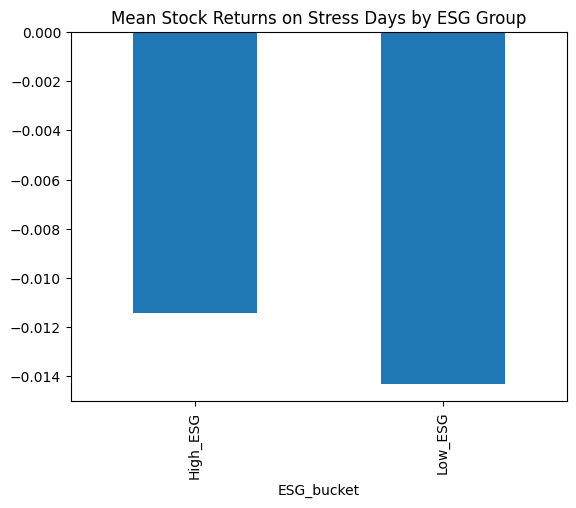

In [32]:
mean_returns.plot(kind='bar', title='Mean Stock Returns on Stress Days by ESG Group')


_Mean daily stock returns on market stress days for High-ESG and Low-ESG firms. High-ESG firms show smaller average losses, indicating greater downside resilience._

##### Understanding drawn from primary hypotheses testing:

- Matches hypothesis direction i.e., difference in performance of high vs low esg score companies on market stress days
- Is economically meaningful i.e., indicates possibility that esg scores can be considered a factor in making decisions regarding investing, budget,etc.
- Is statistically strong (0.3%)

So,we can say

- H3 is NOT disproven
- It is strongly supported so far

__Therefore, continue further analysis__

# 5. ROBUSTNESS CHECK

## 5.1 Check 1:Comparison within each Sector

In [35]:
stress_stock_data.head()

,Date,Stock_Price,Ticker,Stock_Return,Sector,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,marketCap,beta,overallRisk,ESG_bucket,Market_Index,market_return,is_stress
0,2024-01-31,128.171738,A,-0.031129,Health Care,1.12,6.42,6.1,13.64,2.0,39751831552,1.054,8,Low_ESG,4845.649902,-0.016106,True
1,2024-02-13,127.836761,A,-0.019273,Health Care,1.12,6.42,6.1,13.64,2.0,39751831552,1.054,8,Low_ESG,4953.169922,-0.013674,True
2,2024-03-05,142.210526,A,0.010430,Health Care,1.12,6.42,6.1,13.64,2.0,39751831552,1.054,8,Low_ESG,5078.649902,-0.010193,True
3,2024-04-04,139.471329,A,-0.016628,Health Care,1.12,6.42,6.1,13.64,2.0,39751831552,1.054,8,Low_ESG,5147.209961,-0.012334,True
4,2024-04-12,138.869400,A,-0.029448,Health Care,1.12,6.42,6.1,13.64,2.0,39751831552,1.054,8,Low_ESG,5123.410156,-0.014551,True


In [36]:
sector_results = (
    stress_stock_data
    .groupby(['Sector', 'ESG_bucket'])['Stock_Return']
    .mean()
    .reset_index()
)

print(sector_results.head())


                   Sector ESG_bucket  Stock_Return
0  Communication Services   High_ESG     -0.012257
1  Communication Services    Low_ESG     -0.010962
2  Consumer Discretionary   High_ESG     -0.020427
3  Consumer Discretionary    Low_ESG     -0.014542
4        Consumer Staples   High_ESG     -0.002390


In [37]:
sector_pivot = sector_results.pivot(
    index='Sector',
    columns='ESG_bucket',
    values='Stock_Return'
)

sector_pivot['Difference'] = (
    sector_pivot['High_ESG'] - sector_pivot['Low_ESG']
)

print(sector_pivot)


ESG_bucket              High_ESG   Low_ESG  Difference
Sector                                                
Communication Services -0.012257 -0.010962   -0.001294
Consumer Discretionary -0.020427 -0.014542   -0.005885
Consumer Staples       -0.002390 -0.005893    0.003503
Energy                 -0.013142 -0.013555    0.000413
Financials             -0.014187 -0.011445   -0.002741
Health Care            -0.006531 -0.009056    0.002525
Industrials            -0.015180 -0.012406   -0.002774
Information Technology -0.027810 -0.024743   -0.003066
Materials              -0.017736 -0.009730   -0.008006
Real Estate            -0.015511 -0.009900   -0.005611
Utilities              -0.003409 -0.004203    0.000795


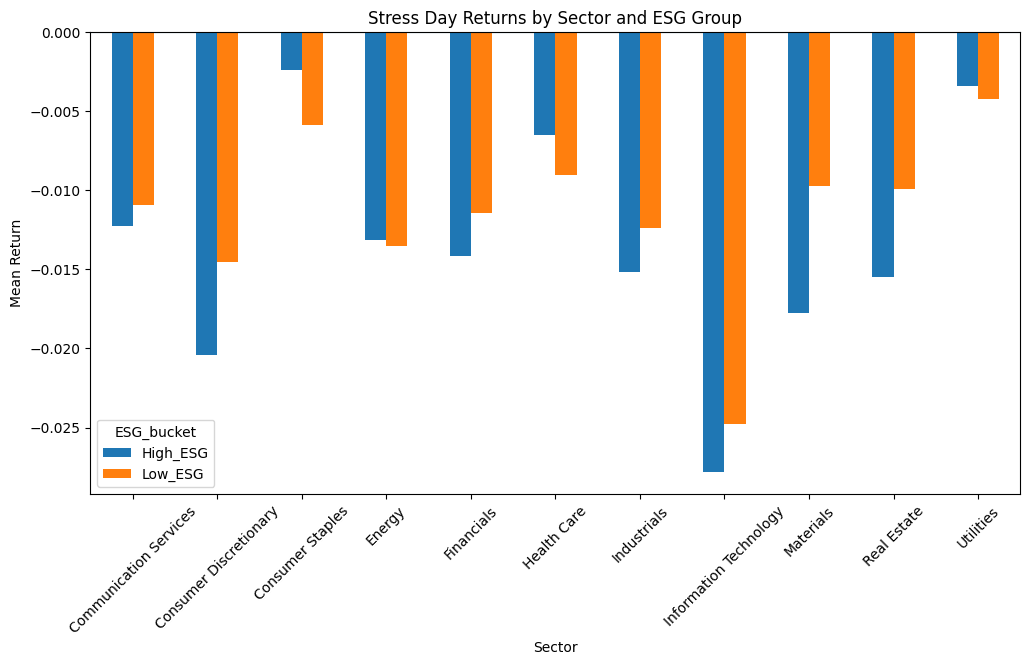

In [38]:
sector_pivot[['High_ESG','Low_ESG']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.axhline(0)
plt.title("Stress Day Returns by Sector and ESG Group")
plt.ylabel("Mean Return")
plt.xticks(rotation=45)
plt.show()


_Sector-level comparison of average stress-day returns for High vs Low ESG firms. Results indicate that the ESG effect varies by sector and is not universal._

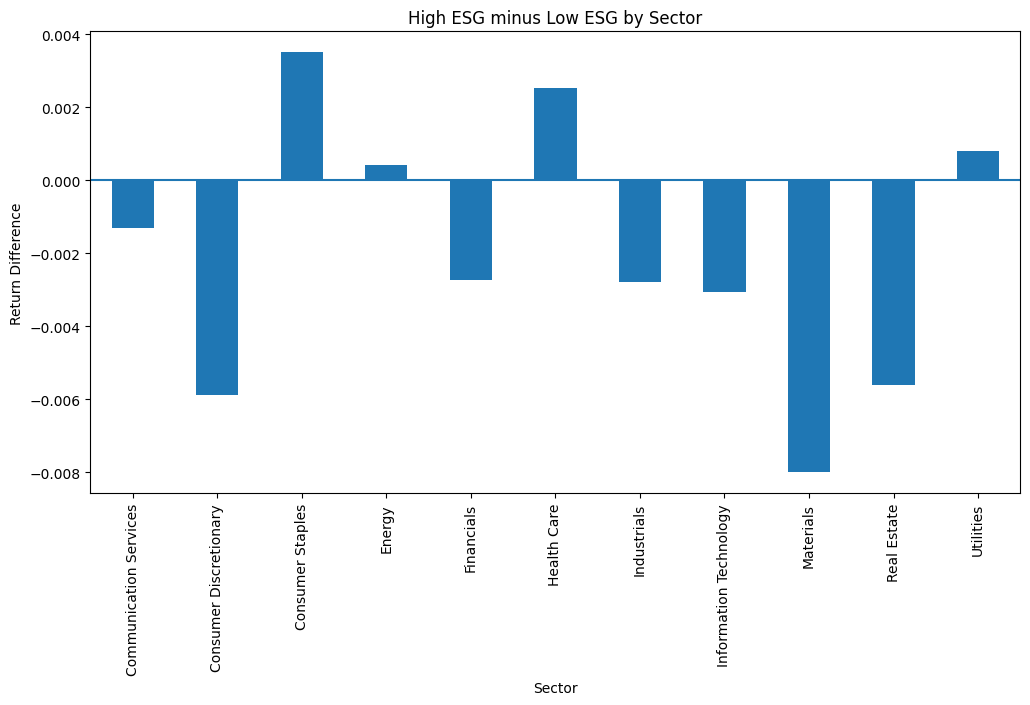

In [39]:
sector_pivot['Difference'].plot(
    kind='bar',
    figsize=(12,6),
    title='High ESG minus Low ESG by Sector'
)

plt.axhline(0)
plt.ylabel("Return Difference")
plt.show()


_Sector-level comparison of average stress-day returns for High vs Low ESG firms. Results indicate that the ESG effect varies by sector and is not universal._

### Check 1 conclusion:

#### ESG advantage is NOT universal across sectors.

It helps mainly in:
- Consumer Staples
- Healthcare
- Utilities
(Defensive sectors)

But in cyclical sectors:
- Tech
- Industrials
- Materials
- Discretionary

High ESG actually fell MORE.

__Key conclusion:__

**Overall strong result is partly driven by: 
_Sector composition_**<br>
__High ESG firms are likely concentrated in defensive sectors. (To be checked next)__

##### ESG category distribution in each sector

In [40]:
company_level = stock_with_esg.drop_duplicates(subset=["Ticker"])

In [41]:
counts_table = pd.crosstab(
    company_level["Sector"],
    company_level["ESG_bucket"]
)

print(counts_table)


ESG_bucket              High_ESG  Low_ESG
Sector                                   
Communication Services         6        6
Consumer Discretionary        17       30
Consumer Staples              27        5
Energy                        15        2
Financials                    28       35
Health Care                   29       21
Industrials                   36       25
Information Technology         6       45
Materials                     16        7
Real Estate                    1       26
Utilities                     27        1


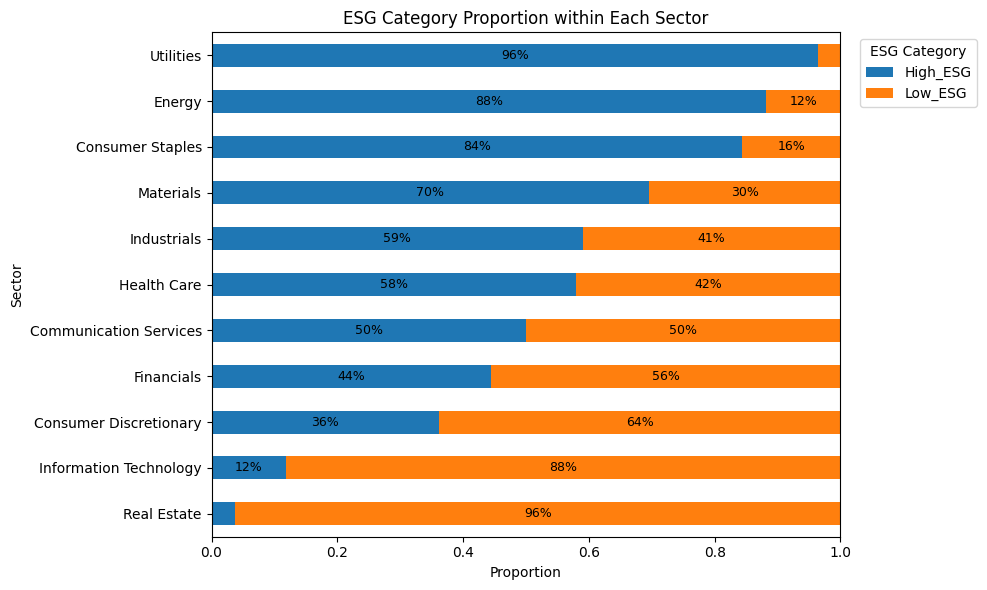

In [42]:
# --- convert to proportions ---
prop_table = counts_table.div(counts_table.sum(axis=1), axis=0).fillna(0)

# --- order sectors by High ESG share ---
prop_table = prop_table.sort_values(by="High_ESG", ascending=True)

# --- plot ---
ax = prop_table.plot(kind="barh", stacked=True, figsize=(10,6))

plt.title("ESG Category Proportion within Each Sector")
plt.xlabel("Proportion")
plt.ylabel("Sector")
plt.xlim(0,1)

# --- add percentage labels inside bars ---
for i, sector in enumerate(prop_table.index):
    cum_width = 0
    for category in prop_table.columns:
        value = prop_table.loc[sector, category]
        if value > 0.05:  # avoid clutter for very small segments
            ax.text(
                cum_width + value/2,
                i,
                f"{value:.0%}",
                va="center",
                ha="center",
                fontsize=9
            )
        cum_width += value

plt.legend(title="ESG Category", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()



_Proportion of High-ESG firms across sectors. High-ESG firms are more concentrated in defensive industries, partially explaining their resilience._

In [43]:
#check percentage of high esg companies which confirms the hypothesis vs which goes against the hypothesis
sectors_to_keep = ["Health Care", "Utilities","Consumer Staples"]

filtered_counts = counts_table.loc[
    counts_table.index.isin(sectors_to_keep)
]

print(filtered_counts['High_ESG'].sum()/(filtered_counts['High_ESG'].sum()+filtered_counts['Low_ESG'].sum()))


0.7545454545454545


In [44]:
#percentage of high esg companies in non-defensive sector
filtered_counts = counts_table.loc[
    ~counts_table.index.isin(sectors_to_keep)
]
print(filtered_counts['High_ESG'].sum()/(filtered_counts['High_ESG'].sum()+filtered_counts['Low_ESG'].sum()))

0.4152823920265781


- Defensive sectors: 75.45% firms are High ESG
- Cyclical sectors: 41.53% firms are High ESG

#### High ESG firms are significantly concentrated in defensive sectors

In [45]:
sector_dist = counts_table.div(counts_table.sum(axis=0), axis=1)
sector_dist

ESG_bucket,High_ESG,Low_ESG
Sector,,
Communication Services,0.028846,0.029557
Consumer Discretionary,0.081731,0.147783
Consumer Staples,0.129808,0.024631
Energy,0.072115,0.009852
Financials,0.134615,0.172414
Health Care,0.139423,0.103448
Industrials,0.173077,0.123153
Information Technology,0.028846,0.221675
Materials,0.076923,0.034483


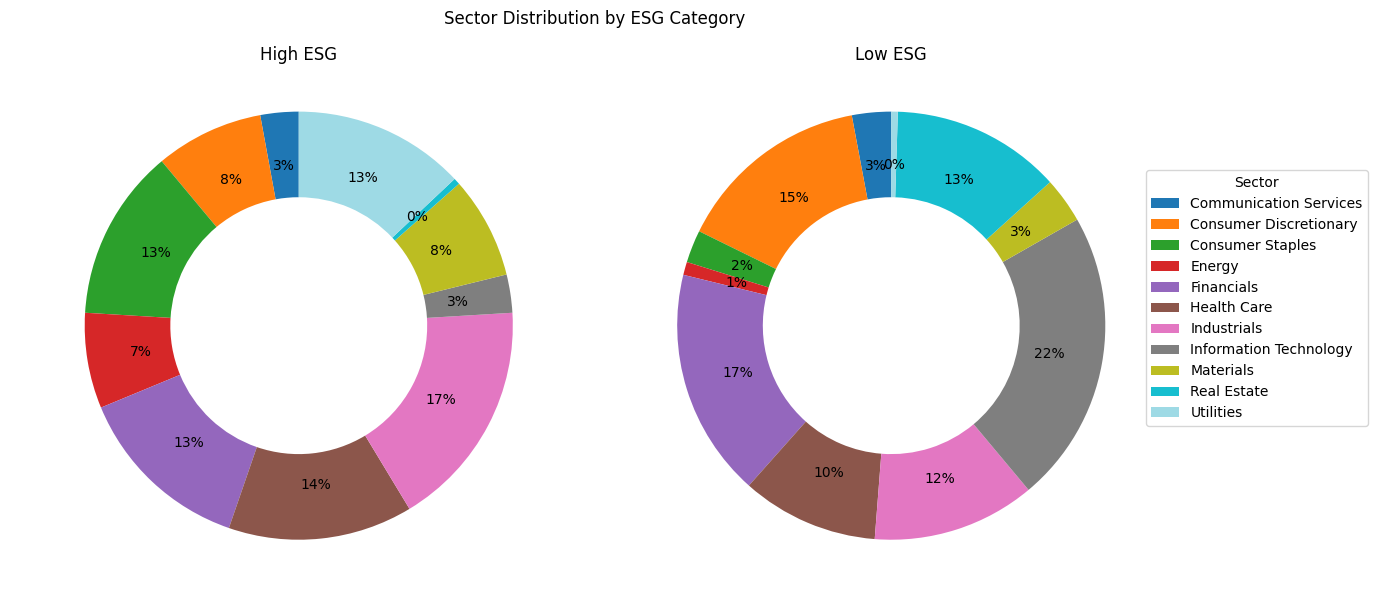

In [46]:
# create a color list matching number of sectors
colors = plt.cm.tab20(np.linspace(0, 1, len(sector_dist.index)))

fig, axes = plt.subplots(1, 2, figsize=(12,6))

wedges1, _, _ = axes[0].pie(
    sector_dist["High_ESG"],
    colors=colors,
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4)
)
axes[0].set_title("High ESG")
axes[0].axis("equal")

wedges2, _, _ = axes[1].pie(
    sector_dist["Low_ESG"],
    colors=colors,  
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4)
)
axes[1].set_title("Low ESG")
axes[1].axis("equal")

fig.legend(
    wedges1,
    sector_dist.index,
    title="Sector",
    loc="center right",
    bbox_to_anchor=(1.15, 0.5)
)

plt.suptitle("Sector Distribution by ESG Category")
plt.tight_layout()
plt.show()

_High ESG and Low ESG companies proportion over different sector. High ESG firms are concentrated in defesive sector._

### Conclusion: High ESG firms are concentrated in defensive sectors

## 5.2 Check 2:Company size Regression

In [47]:
#Encoding ESG bucket as numeric
stress_stock_data['High_ESG_dummy'] = np.where(
    stress_stock_data['ESG_bucket'] == 'High_ESG', 1, 0
)
stress_stock_data

,Date,Stock_Price,Ticker,Stock_Return,Sector,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,marketCap,beta,overallRisk,ESG_bucket,Market_Index,market_return,is_stress,High_ESG_dummy
0,2024-01-31,128.171738,A,-0.031129,Health Care,1.12,6.42,6.10,13.64,2.0,39751831552,1.054,8,Low_ESG,4845.649902,-0.016106,True,0
1,2024-02-13,127.836761,A,-0.019273,Health Care,1.12,6.42,6.10,13.64,2.0,39751831552,1.054,8,Low_ESG,4953.169922,-0.013674,True,0
2,2024-03-05,142.210526,A,0.010430,Health Care,1.12,6.42,6.10,13.64,2.0,39751831552,1.054,8,Low_ESG,5078.649902,-0.010193,True,0
3,2024-04-04,139.471329,A,-0.016628,Health Care,1.12,6.42,6.10,13.64,2.0,39751831552,1.054,8,Low_ESG,5147.209961,-0.012334,True,0
4,2024-04-12,138.869400,A,-0.029448,Health Care,1.12,6.42,6.10,13.64,2.0,39751831552,1.054,8,Low_ESG,5123.410156,-0.014551,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20545,2025-11-06,119.051643,ZTS,-0.007718,Health Care,3.24,6.81,8.72,18.77,2.0,88666619904,0.883,3,Low_ESG,6720.319824,-0.011178,True,0
20546,2025-11-13,120.644844,ZTS,-0.000742,Health Care,3.24,6.81,8.72,18.77,2.0,88666619904,0.883,3,Low_ESG,6737.490234,-0.016557,True,0
20547,2025-11-20,115.397247,ZTS,-0.010164,Health Care,3.24,6.81,8.72,18.77,2.0,88666619904,0.883,3,Low_ESG,6538.759766,-0.015567,True,0
20548,2025-12-12,118.155472,ZTS,0.008499,Health Care,3.24,6.81,8.72,18.77,2.0,88666619904,0.883,3,Low_ESG,6827.410156,-0.010664,True,0


In [48]:
#run regression
import statsmodels.api as sm

X = stress_stock_data[['High_ESG_dummy', 'marketCap']]
X = sm.add_constant(X)

y = stress_stock_data['Stock_Return']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Stock_Return   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     71.97
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           7.15e-32
Time:                        20:48:37   Log-Likelihood:                 47494.
No. Observations:               20550   AIC:                        -9.498e+04
Df Residuals:                   20547   BIC:                        -9.496e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0138      0.000    -55.

### Check 2: conclusion
Regression epression:
Stock_Return = β₀ + β₁(High_ESG_dummy) + β₂(Market_Cap) + error

Where:
High_ESG_dummy = 1 if high ESG, 0 if low ESG

##### - Meaning of coefficient 0.0029

    Holding company size constant:
    High ESG stocks have 0.29% higher return on stress days than low ESG stocks.

(In downturn context, that means fall is smaller by 0.29%)

High ESG firms exhibit slightly higher average returns after controlling for company size, suggesting that ESG-related performance differences are not solely driven by firm size. However, the magnitude of the effect is economically modest, and the low explanatory power indicates that ESG is only one of many factors influencing daily returns.


## Complementary Hypotheses:
#### High ESG companies have lower volatility i.e., smaller daily drops in general market conditions(Using ALL days ,not just stress)

In [49]:
mean_all = stock_with_esg.groupby('ESG_bucket')['Stock_Return'].mean()

print(mean_all)


ESG_bucket
High_ESG    0.000523
Low_ESG     0.000600
Name: Stock_Return, dtype: float64


### Complementary Hypotheses Result: 
#### The difference in performance between high ESG companies vs low ESG companies is insignificant.


# Conclusion

The primary analysis shows that firms with higher ESG scores experienced smaller average losses during market stress days compared to lower-ESG firms. The difference in means is statistically significant, indicating that ESG characteristics are associated with downside resilience in adverse market conditions.

However, sector-level analysis reveals that the ESG effect is not uniform across industries. In several sectors the difference is modest or reversed, suggesting that the relationship between ESG and resilience is context-dependent rather than universal.

Further investigation into sector composition indicates that high-ESG firms are disproportionately concentrated in defensive sectors such as consumer staples, utilities, and healthcare. Because these sectors are structurally less sensitive to economic cycles, part of the observed resilience appears to be driven by industry exposure rather than ESG performance alone. This highlights the importance of accounting for sector effects when interpreting ESG-related outcomes.

Robustness checks strengthen the credibility of the findings. Results remain directionally consistent when:
- Sector-level comparisons are performed
- Firm size is controlled for using regression analysis

The regression results show a positive and statistically significant coefficient for the high-ESG indicator even after controlling for market capitalization, suggesting that ESG retains an independent association with resilience beyond firm size.


## Overall Interpretation

Taken together, the evidence suggests that ESG is associated with improved downside protection, but the mechanism appears to operate partly through sector allocation and firm characteristics rather than representing a purely causal effect. ESG therefore functions as both a signal of firm quality and a proxy for structural exposure to less cyclical industries.

## Implications

For investors, the findings imply that ESG-oriented portfolios may experience lower drawdowns during turbulent periods, though part of this benefit may arise from implicit tilts toward defensive sectors.

For policymakers and researchers, the results highlight the need to distinguish between true ESG effects and structural market composition effects when evaluating the economic impact of sustainability initiatives.

## Limitations

This analysis relies on a single ESG snapshot and a limited time horizon, which may not capture longer-term dynamics or changes in ESG performance. Future research could incorporate multi-year ESG data, alternative stress definitions, and broader market samples to strengthen causal interpretation.